In [1]:
import cv2
import sqlite3
from matplotlib import pyplot as plt
import numpy as np
from operator import itemgetter
from numpy import linalg as LA
from visualize_model import Model
from database import blob_to_array, pair_id_to_image_ids

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
def read_and_show(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

### **INITIAL NOTES**
* Meshes generated during this lab do not fit in the delivery. This is the drive link to the meshes: [mesh.zip (drive)](https://drive.google.com/file/d/1var1Bb9eOOTdcueLsPw9-Qps6a0TtIuT/view?usp=sharing).
* The pdf and html versions of the notebook can't render the 3D plots. If possible, visualize the notebook in the original .ipynb file.

# 1. 3D mesh reconstruction from a set of images from the Gerrard Hall dataset.
Install Colmap and run the automatic reconstruction on the Gerrard Hall dataset

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

We followed the steps described in task 1 from Lab4 and installed COLMAP. After running the reconstruction from the Gerrard Hall dataset, we got the point cloud and saved it as a .ply file to visualize it and clean it from noisy points using Meshlab. The result of the first part is shown in the following image.

One thing to notice is that the building is upside down, which indicates that both programs (COLMAP and Meshlab) use a different coordinate system. We can also see that there are outlier points and a central zone where the actual reconstruction of the scene is.

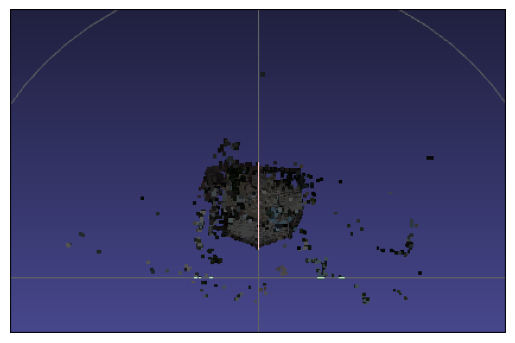

In [3]:
read_and_show('images/default_gh_mesh.png')

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

After rotating, zooming and pruning the outlier points, we have a cleaner view of the 3D scene reconstructed by COLMAP. We can see that the overall shape of the builsing is kept and some facades are more dense and flat than others, for example the front facade is more consistent in its point distribution than the side one. We also notice that there is no roof on top, and that means that no image was taken from above, and thus it was not reconstructed. The same thing happens with the inside of the building.

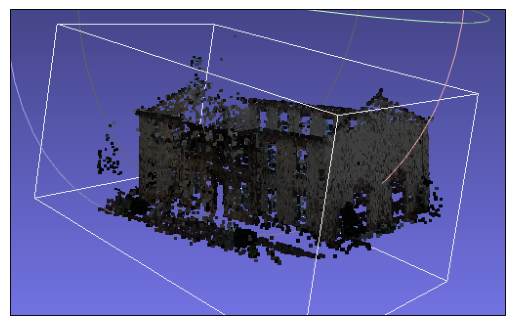

In [4]:
read_and_show('images/prunned_gh_mesh.png')

# 2. Analyze reconstructions using python
## 2.1. Run the notebook, using the Gerrard Hall reconstruction (0.5)
#### <span style='color:Green'> - Add the path to your reconstruction. Answer the questions at the end  </span>

In [5]:
# Add your path
reconstruction_path = "datasets/gerrard-hall/sparse/0"
database_path = "datasets/gerrard-hall/database.db"

#### Load an existing reconstruction and print its contents

In [6]:
model = Model()
model.read_model(reconstruction_path, ext='.bin') # Should also work with .txt

In [7]:
images = model.images
cameras = model.cameras
points3D = model.points3D

In [8]:
print(f"Loaded {len(images)} images. This is the information available for one of them:")
print(images[1])
print(f"\nLoaded {len(cameras)} cameras. This is the information available for one of them:")
print(cameras[1])
print(f"\nLoaded {len(points3D)} 3D points. This is the information available for one of them:")
print(points3D[1])

Loaded 100 images. This is the information available for one of them:
Image(id=1, qvec=array([ 0.63455801,  0.21772048, -0.2481694 ,  0.69881748]), tvec=array([-0.73281431, -1.95589521,  2.79273119]), camera_id=1, name='IMG_2387.JPG', xys=array([[ 758.38574219,   61.36777496],
       [2757.86962891,   11.28521633],
       [2775.62963867,   33.56768417],
       ...,
       [1864.0871582 , 3612.57421875],
       [2398.2121582 , 3603.64233398],
       [2398.2121582 , 3603.64233398]], shape=(12207, 2)), point3D_ids=array([-1, -1, -1, ..., -1, -1, -1], shape=(12207,)))

Loaded 1 cameras. This is the information available for one of them:
Camera(id=1, model='OPENCV', width=5616, height=3744, params=array([ 3.83803762e+03,  3.83702921e+03,  2.80800000e+03,  1.87200000e+03,
       -1.10258229e-01,  7.93837255e-02,  1.16927438e-04,  2.84732815e-04]))

Loaded 42794 3D points. This is the information available for one of them:
Point3D(id=1, xyz=array([-0.06389916, -1.5581926 , -1.62146962]), rgb=

#### Load the database

In [9]:
db = sqlite3.connect(database_path)

In [10]:
keypoints = dict(
        (image_id, blob_to_array(data, np.float32, (-1, 2)))
        for image_id, data in db.execute(
            "SELECT image_id, data FROM keypoints"))

In [11]:
print(f"Loaded keypoints from {len(keypoints)} images. These are the {len(keypoints[1])} keypoints for one of them:")
print(keypoints[1])

Loaded keypoints from 100 images. These are the 24414 keypoints for one of them:
[[7.5838574e+02 6.1367775e+01]
 [4.0777049e+00 2.3697526e+00]
 [2.7578696e+03 1.1285216e+01]
 ...
 [4.2930962e+01 4.8993421e+00]
 [2.3982122e+03 3.6036423e+03]
 [4.2930962e+01 2.5109098e+00]]


In [12]:
matches = dict()
count_no_data = 0
for pair_id, data in db.execute("SELECT pair_id, data FROM matches"):
    if data is None:
        count_no_data += 1
    else:
        matches[pair_id_to_image_ids(pair_id)] = blob_to_array(data, np.uint32, (-1, 2))
print(f"Loaded {len(matches)} matches. {count_no_data}/{len(matches)+count_no_data} matches contained no data")

Loaded 2153 matches. 2797/4950 matches contained no data


In [13]:
print("These are the matches between two images:")
print(matches[1,3])

These are the matches between two images:
[[1459   68]
 [8054  481]
 [8113  482]
 [8114  483]
 [8187  484]
 [6590  512]
 [8009  603]
 [8053  608]
 [8184  611]
 [8111  612]
 [8112  613]
 [8052  774]
 [8182  775]
 [8181  777]
 [5326  783]
 [5806  797]
 [8005  903]
 [8107  907]
 [8110  909]
 [8048  910]
 [8049  911]
 [8180  914]
 [8177  915]
 [8175  916]
 [5067  917]
 [8178  919]
 [5800  926]
 [6416  939]
 [8002 1041]
 [8000 1043]
 [8001 1044]
 [8044 1050]
 [5684 1062]
 [7995 1191]
 [8104 1192]
 [8099 1194]
 [8097 1196]
 [8100 1197]
 [8096 1198]
 [8169 1200]
 [8171 1201]
 [6658 1223]
 [8039 1339]
 [8092 1340]
 [8088 1341]
 [8094 1342]
 [8168 1343]
 [6477 1384]
 [7172 1397]
 [7173 1398]
 [7170 1399]
 [7168 1400]
 [7994 1491]
 [7991 1492]
 [7992 1493]
 [8036 1496]
 [7993 1498]
 [8087 1505]
 [5912 1525]
 [7003 1549]
 [7002 1550]
 [7986 1684]
 [8032 1685]
 [8165 1687]
 [8163 1688]
 [6570 1709]
 [6565 1710]
 [7237 1735]
 [8033 1855]
 [8031 1856]
 [8086 1857]
 [8085 1858]
 [8162 1860]
 [5436 18

#### Visualize the point cloud and cameras

In [14]:
model.create_window()
model.add_points()
model.add_cameras(scale=0.25)
model.show()

#### <span style='color:Green'>  How many keypoints there are in total? </span> 

In [15]:
count_total = 0
for key_array in keypoints.values():
    count_total += key_array.shape[0]

print(f"There are a total of {count_total} keypoints across all images in the dataset.")

There are a total of 2123400 keypoints across all images in the dataset.


#### <span style='color:Green'>  How many 3D points originated from a keypoint in the first image? </span>


In [16]:
count_first_image = [1 for p in points3D.values() if 1 in p.image_ids]
print(f"There are {len(count_first_image)} 3D points originated from a keypoint in the first image.")

There are 2824 3D points originated from a keypoint in the first image.


## 2.2 Plot the 3D points coloured according to the number of images and error. (0.5)

#### <span style='color:Green'> - Plot the 3D points coloured according to the **number of images** from which it originated. </span> Can you extract any conclusions from the visualization? 

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

We decided to plot the 3D points coloured and scaled according to the **number of images** from which they originated. At first, the visualization seems chaotic and senseless, but there is an point cloud of white points in the middle, those are the points from the building, and the others are outliers.

Once we zoom in, we can see that points in the facade of the building are seen by more images than the outliers. We also notice that those points are grouped in flatter and more dense surfaces than those inliers seen by less images. This last group of points is distributed in areas with irregular surfaces, with holes in them due to the sparsity of the points or a mismatch in the depth calculation.

In [17]:
### TO DO 2.2
from plotly import graph_objects as go
import plotly.express as px

pts3d_coords = []
pts3d_num_images = []
pts3d_error = []
for p in points3D.values():
    pts3d_coords.append(p.xyz)
    pts3d_num_images.append(len(p.image_ids))
    pts3d_error.append(p.error)
pts3d_coords = np.stack(pts3d_coords, axis=1)
pts3d_num_images = np.array(pts3d_num_images)
pts3d_num_images_normalized = pts3d_num_images / pts3d_num_images.max()
pts3d_error = np.array(pts3d_error)

fig = px.scatter_3d(x=pts3d_coords[0], y=pts3d_coords[1], z=pts3d_coords[2], color=pts3d_num_images, size=pts3d_num_images, opacity=1.0)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()

#### <span style='color:Green'> - Plot the 3D points coloured according to the **error**. </span> - What is this parameter? Can you extract any conclusions from the visualization?

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

We plotted the 3D points using colour and size as in the last plot. This parameter most likely represents the average reprojection error computed by COLMAP. We expected to see outliers with a higher error than inliers, however that is not the case. There are inlier points with higher error than outlier points. Assuming that the error is the average reprojection error, it could make sense that points seen by 2 images can have less error than those seen by 25 images.

The reasoning behind that is that any measure adds noise to the reading of data, and thus points need to be triangulated and reprojected affected by that noise. That can lead to a good triangulation as we minimize the impact of the noise by averaging the triangulation across multiple images, but the reprojection will not be accurate as the noise from the 3D point is not the same.

However, there are points with high error all around the scene, so the final conclusion we get is that the reprojection error alone is not enough to determine whether a point is part of the building or a noisy point.

In [18]:
### TO DO 2.2
fig = px.scatter_3d(x=pts3d_coords[0], y=pts3d_coords[1], z=pts3d_coords[2], color=pts3d_error, size=pts3d_error, opacity=1.0)
fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()

## 2.3 Plot the 3D points that correspond to a keypoint in the first image. Also plot the image with the keypoints (1.0)


<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

These are the 3D points from the first image. It has a flat shape with some rectangular shaped holes that could be the doors of the facade. 

In [19]:
### TO DO 2.3
pts3d_image1 = []
for p in points3D.values():
    if 1 in p.image_ids:
        pts3d_image1.append(p.xyz)
pts3d_image1 = np.stack(pts3d_image1, axis=1)

fig = go.Figure(layout=dict(height=400, width=550))
fig.add_trace(go.Scatter3d(x=pts3d_image1[0], y=pts3d_image1[1], z=pts3d_image1[2], mode='markers', marker=dict(size=2, color="black", opacity=0.5)))
fig.show()
# fig = px.scatter_3d(x=pts3d_image1[0], y=pts3d_image1[1], z=pts3d_image1[2], size=np.ones_like(pts3d_image1[0]) * 0.5, opacity=1.0)
# fig.show()

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

As we can see below, these points are distributed across the facade and the trees beside the building. The doors and sky have almost no keypoints, likely due to a smooth surface with no descriptors. The shape matches that one from the previous plot, with horizontal lines on the door hole and a diagonal rooftop line.

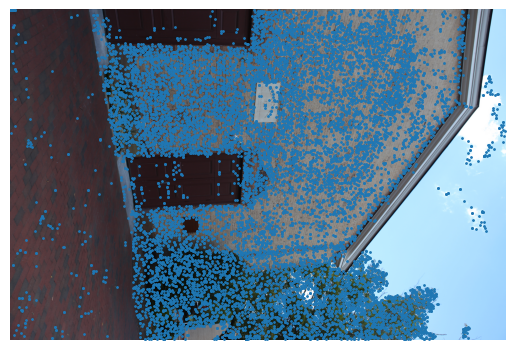

In [20]:
img = cv2.imread(f"datasets/gerrard-hall/images/{images[1].name}")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.scatter(keypoints[1][:, 0], keypoints[1][:, 1], s=1)
plt.axis('off')
plt.show()

## 2.4 Create a visualization for the number of matches between all images. (1.0)
For example: https://seaborn.pydata.org/generated/seaborn.heatmap.html

Assuming that images from the dataset followed a spatial order, like taken as a sequence and therefore image 1 and image 2 should be close, we see in the heatmap that images far apart have matches between them. COLMAP may read the images in a different order and that causes the heatmap to be this chaotic instead of a big diagonal relating images with their neighbours. What we do see is that the main diagonal is blank because COLMAP does not look for matches of an image with the same image, and there is a symmetry respect the diagonal because matches are two-ways connected.

<Axes: >

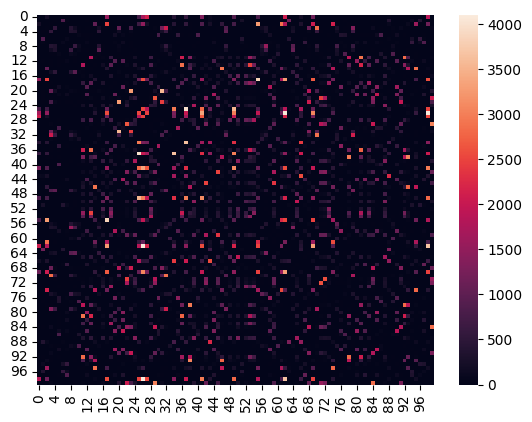

In [21]:
### TO DO 2.4
import seaborn as sns

match_array = np.zeros((101, 101))
for k, m in matches.items():
    match_array[k[0], k[1]] = len(m)
    match_array[k[1], k[0]] = len(m)


sns.heatmap(match_array[1:, 1:])

## 2.5 Visualize the keypoints and matches between the two images used in lab 3 using Colmap, how it compares to the results from lab 3? (1.0)
#### <span style='color:Green'> You can use the GUI to get the keypoints and matches and then visualize it here, following the same style as in lab 3 to get comparable results. </span>

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

The explanation and comparison of this task is below the images, for convenience and better visualization of the results while reading the conclusions we got.

In [22]:
def fundamental_matrix(points1, points2):

    def _to_homogeneous(pts):
        pts = np.asarray(pts, dtype=np.float64)

        if pts.shape[0] in (2, 3) and pts.shape[1] not in (2, 3):
            # likely (2,N) or (3,N)
            pts = pts.T

        if pts.shape[1] == 2:
            ones = np.ones((pts.shape[0], 1), dtype=np.float64)
            pts_h = np.hstack([pts, ones])
            return pts_h

        if pts.shape[1] == 3:
            return pts

    def _normalize_points(pts_h):
        """
        Hartley-style normalization:
        - Translate so centroid is at origin
        - Scale so mean squared distance to origin is 1 (as stated in the slides)
        Returns:
            pts_n: normalized points (N,3)
            H: normalization transform (3,3) such that pts_n ~ H @ pts_h^T
        """
        pts_h = np.asarray(pts_h, dtype=np.float64)

        # Dehomogenize safely for centroid/scale computation
        w = pts_h[:, 2:3]
        w_safe = np.where(np.abs(w) < 1e-12, 1e-12, w)
        pts_e = pts_h[:, 0:2] / w_safe  # (N,2)

        centroid = np.mean(pts_e, axis=0)  # (cx, cy)

        d = pts_e - centroid  # (N,2)
        msd = np.mean(np.sum(d**2, axis=1))  # mean squared distance

        if msd < 1e-12:
            s = 1.0
        else:
            s = 1.0 / np.sqrt(msd)

        cx, cy = centroid
        H = np.array([
            [s, 0.0, -s * cx],
            [0.0, s, -s * cy],
            [0.0, 0.0, 1.0]
        ], dtype=np.float64)

        pts_n = (H @ pts_h.T).T  # (N,3)
        return pts_n, H


    # 0. Convert to homogeneous if necessary
    p1 = _to_homogeneous(points1)
    p2 = _to_homogeneous(points2)

    # 1. Normalize points
    q1, H1 = _normalize_points(p1)
    q2, H2 = _normalize_points(p2)

    # Dehomogenize normalized points for W construction
    q1 = q1 / np.where(np.abs(q1[:, 2:3]) < 1e-12, 1e-12, q1[:, 2:3])
    q2 = q2 / np.where(np.abs(q2[:, 2:3]) < 1e-12, 1e-12, q2[:, 2:3])

    u  = q1[:, 0]
    v  = q1[:, 1]
    up = q2[:, 0]
    vp = q2[:, 1]

    # 2. Build W (Nx9)
    #    row = [u'*u, u'*v, u', v'*u, v'*v, v', u, v, 1]
    W = np.column_stack([
        up * u,  up * v,  up,
        vp * u,  vp * v,  vp,
        u,       v,       np.ones_like(u)
    ])

    # 3. SVD(W) -> f is last column of V
    Uw, Sw, Vtw = np.linalg.svd(W, full_matrices=True)
    f = Vtw[-1, :]  # last row of V^T = last column of V

    # 4. Compose F_rank3 (3x3)
    F_rank3 = f.reshape(3, 3)

    # 5-7. Enforce rank-2 constraint on F (SVD, zero last singular value)
    Uf, Sf, Vtf = np.linalg.svd(F_rank3)
    Sf[2] = 0.0
    F_rank2 = Uf @ np.diag(Sf) @ Vtf

    # 8. De-normalize: F = H2^T * F_rank2 * H1
    F = H2.T @ F_rank2 @ H1

    return F


def Ransac_fundamental_matrix(points1, points2, th, max_it_0):
    """
    Args:
        points1: points in image 1
        points2: points in image 2
        th: threshold on Sampson error 
        max_it_0: user predefined number of iterations 

    Returns:
        F: (3,3) Fundamental matrix
        inliers: list of int indices of inlier correspondences
    """

    def _to_3xN(pts):
        pts = np.asarray(pts, dtype=np.float64)
        if pts.ndim != 2:
            raise ValueError("points must be a 2D array")

        # If it's 2xN or 3xN, keep; if it's Nx2 or Nx3, transpose
        if pts.shape[0] in (2, 3) and pts.shape[1] not in (2, 3):
            # 2xN or 3xN
            pass
        else:
            # likely Nx2 or Nx3
            pts = pts.T

        if pts.shape[0] == 2:
            pts = np.vstack([pts, np.ones((1, pts.shape[1]), dtype=np.float64)])
        elif pts.shape[0] != 3:
            raise ValueError("points must be (2,N)/(3,N) or (N,2)/(N,3)")

        return pts  

    def _sampson_error(F, x1_3xN, x2_3xN, eps=1e-12):
        """
        Sampson error (PDF):
            (x2^T F x1)^2 / ( (Fx1)_1^2 + (Fx1)_2^2 + (F^T x2)_1^2 + (F^T x2)_2^2 )
        Returns: (N,) array
        """
        Fx1 = F @ x1_3xN          # 3xN
        Ftx2 = F.T @ x2_3xN       # 3xN
        x2tFx1 = np.sum(x2_3xN * Fx1, axis=0)  # (N,)

        denom = Fx1[0, :]**2 + Fx1[1, :]**2 + Ftx2[0, :]**2 + Ftx2[1, :]**2
        denom = np.maximum(denom, eps)

        return (x2tFx1**2) / denom

    # 1.Prepare points as 3xN 
    x1 = _to_3xN(points1)
    x2 = _to_3xN(points2)

    if x1.shape[1] != x2.shape[1]:
        raise ValueError("points1 and points2 must have same number of correspondences")

    N = x1.shape[1]
    if N < 8:
        raise ValueError("Need at least 8 correspondences")

    # 2.RANSAC params 
    s = 8
    p_success = 0.99
    th = float(th)

    rng = np.random.default_rng()

    best_F = None
    best_inliers_idx = np.array([], dtype=int)
    best_count = 0

    it = 0
    max_it = int(max_it_0)

    # 3.RANSAC loop 
    while it < max_it:
        idx = rng.choice(N, size=s, replace=False)

        try:
            F_cand = fundamental_matrix(x1[:, idx].T, x2[:, idx].T)  # pass as Nx3 (8x3)
        except Exception:
            it += 1
            continue

        # Compute Sampson error for all correspondences
        err = _sampson_error(F_cand, x1, x2)

        inliers_idx = np.where(err < th)[0]
        count = int(inliers_idx.size)

        if count > best_count:
            best_count = count
            best_inliers_idx = inliers_idx
            best_F = F_cand

            # Update estimated iterations (ensure 0.99 prob. of all-inlier sample)
            w = best_count / float(N)
            w = np.clip(w, 0.0, 1.0)

            if w >= 1.0 - 1e-12:
                N_est = 1.0
            else:
                denom = 1.0 - (w ** s)
                denom = np.clip(denom, 1e-12, 1.0 - 1e-12)
                N_est = np.log(1.0 - p_success) / np.log(denom)
                if not np.isfinite(N_est):
                    N_est = float(max_it_0)

            # maximum between user max and estimated max
            max_it = int(np.ceil(max(float(max_it_0), float(N_est))))

            # Safety cap to avoid absurd iteration counts 
            max_it = min(max_it, 200000)

        it += 1

    # 4.Refit with best inliers 
    if best_F is None or best_count < 8:
        F_all = fundamental_matrix(x1.T, x2.T)
        err_all = _sampson_error(F_all, x1, x2)
        inl_all = np.where(err_all < th)[0].astype(int).tolist()
        return F_all, inl_all

    # 5.Refine F with all inliers and recompute inliers once
    F_ref = fundamental_matrix(x1[:, best_inliers_idx].T, x2[:, best_inliers_idx].T)
    err_ref = _sampson_error(F_ref, x1, x2)
    inliers_ref = np.where(err_ref < th)[0].astype(int)

    return F_ref, inliers_ref.tolist()


Num matches lab3 method: 686


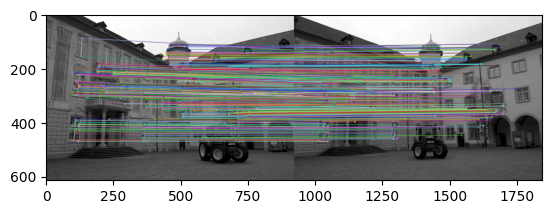

Num matches COLMAP method: 1693


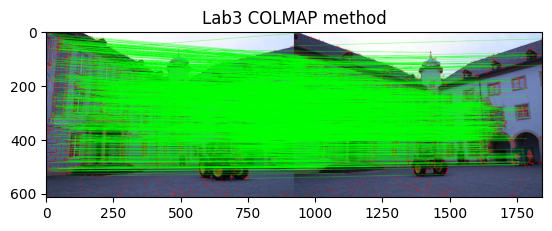

In [23]:
### TO DO 2.5
img1 = cv2.imread('datasets/lab3_imgs/images/0001_s.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('datasets/lab3_imgs/images/0002_s.png', cv2.IMREAD_GRAYSCALE)
h, w = img1.shape

# Initiate ORB detector
orb = cv2.ORB_create(3000)
# find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(img1,None)
kp2, des2 = orb.detectAndCompute(img2,None)

# Keypoint matching
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1,des2)

# Robust estimation of the fundamental matrix #
points1 = []
points2 = []
for m in matches:
    points1.append([kp1[m.queryIdx].pt[0], kp1[m.queryIdx].pt[1], 1])
    points2.append([kp2[m.trainIdx].pt[0], kp2[m.trainIdx].pt[1], 1])
    
points1 = np.asarray(points1)
points1 = points1.T
points2 = np.asarray(points2)
points2 = points2.T

F, indices_inlier_matches = Ransac_fundamental_matrix(points1, points2, 1, 5000)
inlier_matches = itemgetter(*indices_inlier_matches)(matches)

print(f"Num matches lab3 method: {len(inlier_matches)}")
img_12 = cv2.drawMatches(img1,kp1,img2,kp2,inlier_matches,None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
fig = plt.figure()
plt.imshow(img_12)
plt.show()

img = cv2.imread("images/lab3_img12_matches_colmap.png", cv2.IMREAD_COLOR_RGB)
database_path = "datasets/lab3_imgs/database.db"
db = sqlite3.connect(database_path)

matches = dict()
count_no_data = 0
for pair_id, data in db.execute("SELECT pair_id, data FROM matches"):
    if data is None:
        count_no_data += 1
    else:
        matches[pair_id_to_image_ids(pair_id)] = blob_to_array(data, np.uint32, (-1, 2))

print(f"Num matches COLMAP method: {len(matches[1, 2])}")
plt.imshow(img)
plt.title("Lab3 COLMAP method")
plt.show()

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

For the first case we used the same method as Lab3 and showed the results in the same way, which got us 710 matches between the 2 images to match. On the second case, we used the feature extraction and matching steps from COLMAP, and the visualization tool of matches from COLMAP as well which has the option to save the generated visualization of the matches. This second method gave us 1693 matches.

COLMAP's method provides more than double the inlier matches than Lab3's method, covering zones such as the leftmost part of the left facade and the rightmost part of the right facade. It also provides more density of points in the same area. We can also see that COLMAP's visualization also shows keypoints with no match as red points without the green lines. Those are mostly on the floor and could not be matched probably because they are too similar from one another and it is difficult to differentiate between them. It may be possible to relate them once we triangulate.

## 2.6 Triangulate and visualize the 3D points from the keypoints extracted using Colmap on the two images used in lab 3, how it compares to the results from lab 3? (1.0) 
#### <span style='color:Green'> - Use the triangulation from lab 3 to the get the 3D points and visualize them following the same style. </span>

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

Using COLMAP's default configuration, the 3D reconstruction is rejected. However, following the advice found in [COLMAP's FAQ](https://colmap.github.io/faq.html#increase-number-of-matches-sparse-3d-points), by unchecking the *ignore_two_view_tracks* option COLMAP does not reject the reconstruction anymore. As an extra measure, we also change the *min_model_size* to 1 instead of 10, as it could be related to the minimum number of images that the model needs to do the reconstruction.

One of the outputs of the reconstruction are the camera intrinsics and poses, which we used to triangulate using the method from Lab3. The results are after the code for a better visualization of the plot while reading our conclusions.

In [24]:
from collections.abc import Iterable
from typing import Optional

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from mpl_toolkits.mplot3d import Axes3D


def projective2img(x):
    """
    Take a 3D homogenous/projective coordinate and obtain the 2D (image) euclidean equivalent
    """
    assert x.shape[0] == 3, f'`x` shape {x.shape} expected (3,...)'
    return x[:2, ...] / x[2][np.newaxis]


def img2projective(x):
    """
    Take a 2D image coordinate and add the 3th dimension of homogenous/projective coordinate
    """
    assert x.shape[0] == 2, f'`x` shape {x.shape} expected (2,...) '
    return np.vstack((x, np.ones_like(x[0, ...])))


def homogeneous2euclidean(x):
    """
    Take a 4D homogenous coordinate and normalize to obtain the 3D euclidan equivalent
    Take a 3D homogenous/projective coordinate and obtain the 2D (image) euclidean equivalent
    """
    assert x.shape[0] == 4, f'`x` shape {x.shape} expected (4,...)'
    return x[:3, ...] / x[3][np.newaxis]


def euclidean2homogeneous(x):
    """
    Take a 3D euclidean coordinate and add the 4th dimension of homogenous cordinate
    """
    assert x.shape[0] == 3, f'`x` shape {x.shape} expected (3,...) '
    return np.vstack((x, np.ones_like(x[0, ...])))


def line_draw(line, canv, size):
    def get_y(t):
        return -(line[0] * t + line[2]) / line[1]

    def get_x(t):
        return -(line[1] * t + line[2]) / line[0]

    w, h = size

    if line[0] != 0 and abs(get_x(0) - get_x(w)) < w:
        beg = (get_x(0), 0)
        end = (get_x(h), h)
    else:
        beg = (0, get_y(0))
        end = (w, get_y(w))
    canv.line([beg, end], width=4)


def plot_img(img, do_not_use=[0]):
    plt.figure(do_not_use[0])
    do_not_use[0] += 1
    plt.imshow(img)


def optical_center(P):
    u, s, vh = np.linalg.svd(P)
    o = vh[:, -1]
    o = o[:3] / o[3]

    return o


def view_direction(P, x):
    v, resid, rank, s = np.linalg.lstsq(P[:, :3], x, rcond=None)
    return v


def draw_points(points, ax=None, **plot_kwargs):
    # Creating figure
    if ax is None:
        fig = plt.figure(figsize=(10, 7))
        ax = plt.axes(projection="3d")
    # Creating plot
    ax.scatter3D(points[:, 0], points[:, 1], points[:, 2], **plot_kwargs)


def draw_lines(points, ax: Optional[Axes3D] = None, **line_kwargs):
    """
    :param points: shape (num_points, 2, 3)
    :param ax:
    :return:
    """
    if ax is None:
        fig = plt.figure(figsize=(10, 7))
        ax = plt.axes(projection="3d")
    assert isinstance(ax, Axes3D)

    for l in points:
        p1, p2 = l[0], l[1]
        ax.plot(xs=[p1[0], p2[0]], ys=[p1[1], p2[1]], zs=[p1[2], p2[2]], **line_kwargs)


def get_camera_frame_points(P, w, h, scale, ax=None):
    """
    :param P: Camera matrix
    :param w: Width
    :param h: Height
    :param scale: Scale
    :return:
    """
    o = optical_center(P)
    p1 = o + view_direction(P, np.array([0, 0, 1])) * scale
    p2 = o + view_direction(P, np.array([w, 0, 1])) * scale
    p3 = o + view_direction(P, np.array([w, h, 1])) * scale
    p4 = o + view_direction(P, np.array([0, h, 1])) * scale

    points = np.array([[o, p1]])
    points = np.vstack((points, np.array([[o, p2]])))
    points = np.vstack((points, np.array([[o, p3]])))
    points = np.vstack((points, np.array([[o, p4]])))
    points = np.vstack((points, np.array([[p1, p2]])))
    points = np.vstack((points, np.array([[p2, p3]])))
    points = np.vstack((points, np.array([[p3, p4]])))
    points = np.vstack((points, np.array([[p4, p1]])))
    return points


def plot_camera(P, w, h, scale, ax=None, **plot_kwargs):
    """
    :param P: Camera matrix
    :param w: Width
    :param h: Height
    :param scale: Scale
    :param ax: matplotlib axis
    :return:
    """
    points = get_camera_frame_points(P, w, h, scale)
    draw_lines(points, ax=ax, **plot_kwargs)

def line_draw(line, canv, size):
    def get_y(t):
        return -(line[0] * t + line[2]) / line[1]

    def get_x(t):
        return -(line[1] * t + line[2]) / line[0]

    w, h = size

    if line[0] != 0 and abs(get_x(0) - get_x(w)) < w:
        beg = (get_x(0), 0)
        end = (get_x(h), h)
    else:
        beg = (0, get_y(0))
        end = (w, get_y(w))
    canv.line([beg, end], width=4)


def plot_img(img, do_not_use=[0]):
    plt.figure(do_not_use[0])
    do_not_use[0] += 1
    plt.imshow(img)


In [25]:
# Write here the method for DLT triangulation
def triangulate(x1, x2, P1, P2, imsize) -> np.ndarray:
    assert P1.shape == (3,4) == P2.shape
    assert x1.shape == x2.shape and x1.shape[0] == 3
    '''
    Your implementation here
    '''
    # DLT approach
    # Step 0: Ensure homogeneous coordinates x1 and x2 have form of [x, y, 1]
    x1 = x1 / x1[2]
    x2 = x2 / x2[2]
    
    # Step 1: Normalize coordinates with matrix H
    H = np.array([
        [2 / imsize[0],      0,        -1],
        [     0,        2 / imsize[1], -1],
        [     0,             0,         1]
    ])
    x1_norm = H @ x1
    x2_norm = H @ x2
    P1_norm = H @ P1
    P2_norm = H @ P2

    # Step 2: Compute matrix A
    A = np.stack([
        x1_norm[0:1].T @ P1_norm[2:3] - P1_norm[0:1],
        x1_norm[1:2].T @ P1_norm[2:3] - P1_norm[1:2],
        x2_norm[0:1].T @ P2_norm[2:3] - P2_norm[0:1],
        x2_norm[1:2].T @ P2_norm[2:3] - P2_norm[1:2],
    ], axis=0).transpose(1, 0, 2) # Shape: 4 x n_points x 4 -> n_points x 4 x 4

    # Step 3: SVD decomposition to extract right null-vector (last column of V, last row of V transposed)
    _, _, Vh = LA.svd(A) 
    X_trian = Vh[:, -1] # Shape: n_points x 4
    return X_trian.T # Shape: 4 x n_points

    

In [26]:
keypoints = dict(
        (image_id, blob_to_array(data, np.float32, (-1, 2)))
        for image_id, data in db.execute(
            "SELECT image_id, data FROM keypoints"))

x1 = []
x2 = []
for m in matches[1, 2]:
    x1.append(keypoints[1][m[0]])
    x2.append(keypoints[2][m[1]])
x1 = np.array(x1).T
x2 = np.array(x2).T

x1 = img2projective(x1)
x2 = img2projective(x2)

print(f"{x1.shape=}")
print(f"{x2.shape=}")

x1.shape=(3, 1693)
x2.shape=(3, 1693)


In [27]:
reconstruction_path = "datasets/lab3_imgs/sparse/0"
model = Model()
model.read_model(reconstruction_path, ext=".bin")

images = model.images
cameras = model.cameras

def get_camera_matrix(camera, image):
    # P = K @ [R | t]
    K = np.eye(3)
    K[0,0] = camera.params[0]
    K[1,1] = camera.params[0]
    K[0,2] = camera.params[1]
    K[1,2] = camera.params[2]

    R = image.qvec2rotmat()
    t = image.tvec
    Rt = np.concat([R, t[..., np.newaxis]], axis=1)
    assert Rt.shape == (3, 4)

    P = K @ Rt
    assert P.shape == (3, 4)

    return P, K, Rt

P1, K1, Rt1 = get_camera_matrix(cameras[1], images[1])
P2, K2, Rt2 = get_camera_matrix(cameras[2], images[2])



Camera 2:
  Points in front of Cam1: 958/1693
  Points in front of Cam2: 958/1693
  Points in front of BOTH: 958/1693
  Score: 958


/tmp/ipykernel_20313/31299600.py:50: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



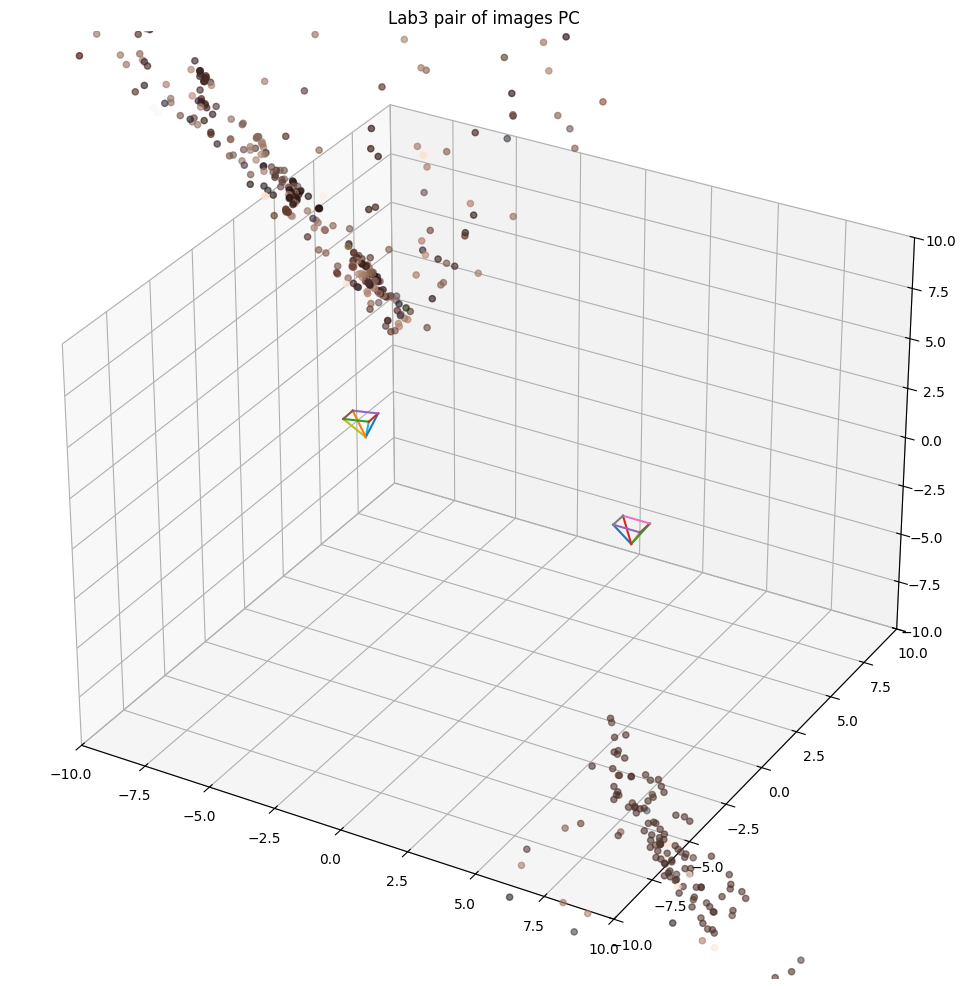

In [28]:
# img1 = cv2.imread('Data/0000_s.png', cv2.IMREAD_UNCHANGED)
img1 = cv2.imread('datasets/lab3_imgs/images/0001_s.png', cv2.IMREAD_UNCHANGED)
H, W, C = img1.shape
assert C == 3 or C == 1

# Estimate by triangulation the 3D coordinates of the matches
X_pred = triangulate(x1, x2, P1, P2, [W, H])
X_eucl = homogeneous2euclidean(X_pred)

# Prepare figure
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')
low_lim, up_lim = -10, 10

# Render the 3D point cloud
x_img = np.transpose(x1[:2]).astype(int)
rgb_txt = (img1[x_img[:, 1], x_img[:, 0]]) / 255
draw_points(X_eucl.T, color=rgb_txt, ax=ax)
plot_camera(P1, W, H, 1, ax=ax)
plot_camera(P2, W, H, 1, ax=ax)
ax.set_title(f"Lab3 pair of images PC")
ax.set_xlim(low_lim, up_lim)
ax.set_ylim(low_lim, up_lim)
ax.set_zlim(low_lim, up_lim)

# Check depth in camera 1
depths_cam1 = X_pred[2, :]  # Z coordinate in homogeneous (before normalization)

# Check depth in camera 2
# Transform points to camera 2 coordinate system
P2_normalized = np.linalg.inv(K2) @ P2
X_cam2 = P2_normalized @ X_pred  # Project to camera 2
depths_cam2 = X_cam2[2, :]

# Count how many points are in front of both cameras
in_front_cam1 = np.sum(depths_cam1 > 0)
in_front_cam2 = np.sum(depths_cam2 > 0)
both_positive = np.sum((depths_cam1 > 0) & (depths_cam2 > 0))

# Score is the number of points with positive depth in both cameras
score = both_positive

print(f"\nCamera 2:")
print(f"  Points in front of Cam1: {in_front_cam1}/{len(depths_cam1)}")
print(f"  Points in front of Cam2: {in_front_cam2}/{len(depths_cam2)}")
print(f"  Points in front of BOTH: {both_positive}/{len(depths_cam1)}")
print(f"  Score: {score}")

fig.tight_layout()
fig.show()



<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

The expected result would be to see all points in front of both cameras, however some of the points are behind both cameras. As mentioned earlier, COLMAP uses a coordinate system that does not match the one in Meshlab, and the starting point of most 3D visualizations in this notebook are rotated in some way. We think that is what is causing the output to be this strange. Another possibility could be the triangulation method, maybe the camera poses and intrinsics are extracted using a geometric approach rather than the DLT as we did in Lab3, and the difference in the accuracy of both methods could cause that, but we believe that as an unlikely case because the difference would be smaller than placing almost half points behind both cameras.

## 2.7 Visualize the sparse reconstruction using the 2 images from lab 3, and the complete CASTLE dataset. Comment on the differences between techniques and number of images used. (1.0)
#### <span style='color:Green'> - Use the reconstruction from Colmap to the get the 3D points and visualize them following the same style, using two images and the complete dataset. </span>

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

We show as the result of the two view reconstruction the output of the process we used for the previous task. We can see that the points present some points which could be either outliers or part of the floor, and two regions which are be the facades of the building seen by both images.
For the two view images we kept the results from the process described before, and visualize the output in Meshlab. For the full Castle dataset, we used the default parameters of COLMAP's automatic reconstruction. We will call the first image *two_view* and the second one *castle_view* from now on.

As we can see, the *two_view* model are two facades of the *castle_view* model. One notable difference is outliers are better perceived in the *castle_view* model, there are even more outliers that could not fit inside the reported image. Nonetheless, this can be cleaned by manually deleting those vertices using Meshlab.

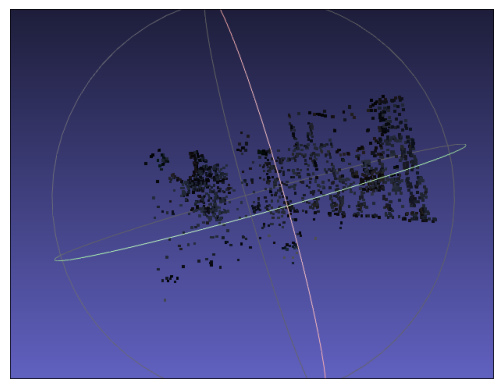

In [29]:
### TO DO 2.7
read_and_show("images/twoview_lab3_mesh.png")

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

For the full Castle dataset, we used the default reconstruction parameters from the automatic reconstruction from COLMAP. The result we see is a more complete reconstruction with some noisy points floating beyond the building's area. The facades of the building are more recognizable, and we can even see some texture in the most dense areas of the scene.

We see that the more images we have, the better is the reconstruction in terms of density of points and in a visual perception of the original shape of the scene. We did not overlap both models to see if the two images reconstruction would fit in some part of the full reconstruction because there is a mismatch in position, rotation and scale, but if we did we think that the points would not match. That is because the points from the two view images would have been triangulated using more images and therefore their 3D position would have been altered.

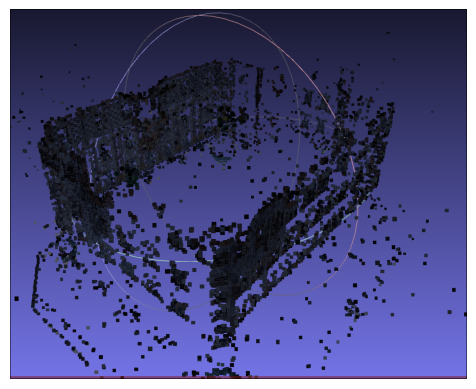

In [30]:
read_and_show("images/castle_sparse_mesh.png")

# 3. Configure the reconstruction to improve the results. (1.0)
Configure the reconstruction to get the best possible mesh, explain the parameters changed and why you decided to change them. Remove noisy points with Meshlab or others.

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

To improve the reconstruction we provide the result from the dense reconstruction generated from the automatic reconstruction pipeline with the dense option checked, as well as the use of GPU to accelerate part of the process. So the dense reconstruction shown in the next image, comes from the sparse reconstruction we saw in the previous task.
We decided to do the sparse reconstruction and dense reconstruction of the full Castle dataset at once using the automatic reconstruction option from Meshlab. Therefore, the previous sparse reconstruction is part of the same pipeline.

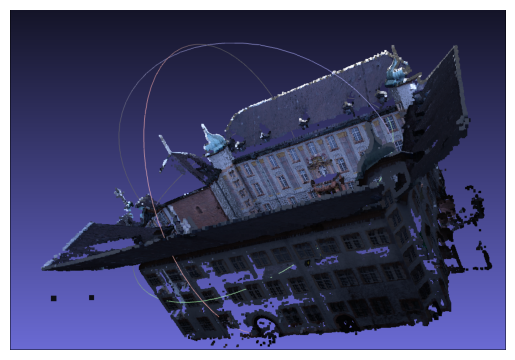

In [31]:
read_and_show("images/castle_dense_mesh.png")

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

As a next step, we pruned the noisy points from the mesh, but there were almost no noisy points and the improvement is only percieved by the absence of the points in th eleft part of the image.

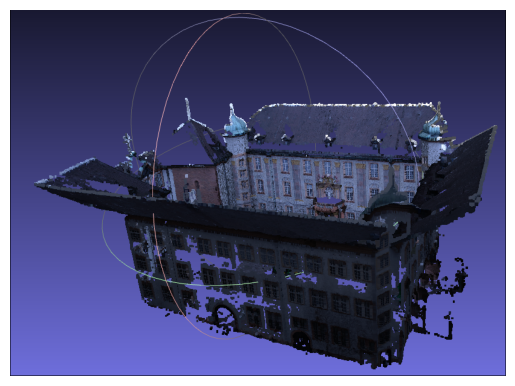

In [32]:
read_and_show("images/castle_dense_clean_mesh.png")

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

For the final step, we decided to refine the process further using the *poisson mesher*, which smoothens the surfaces and fills some holes that are seen in the facade closer to the camera. But it has its downsides, as parts that did not have enough density of points disappeared leaving behind some holes in the same facade. The only parameter we explicitly set was the Trim, which was set to 10.

The result could be improved further by tweaking the parameters further but this reconstruction took a while to complete and we had no time to continue testing.

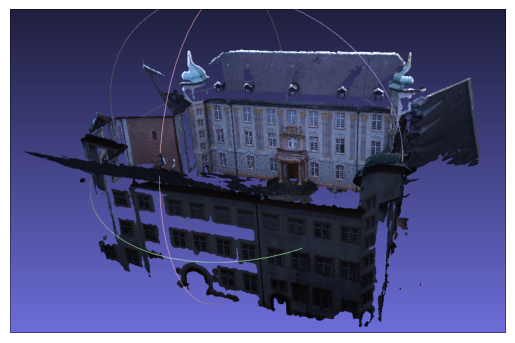

In [33]:
read_and_show("images/castle_poisson_clean_mesh.png")

# 4. Reconstruct a 3D mesh from images captured by you

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

We captured the scene of a flamingo plushie on top of a table. The idea was to present a challenge to COLMAP with to the "hairy" plushie to see its limitations and strengths. This reconstruction was generated using 51 images taken at around the same altitude, with almost no tilt of the camera, in an indoor scenario around the scene. We passed the dataset to COLMAP doing each step of the reconstruction separately from feature extraction to poisson meshing keeping the same parameters as with the previous Castle dataset. As a last step, we prunned it using Meshlab to remove the partially reconstructed chairs, walls and furniture.

Given a sample image of the dataset for comparison, we see that the center of the table is well reconstructed. It is a flat surface with the painted patterns almost identical to the shown sample image. However, when we get further away from the table the surface gets more unstable. That is because there are less points in those areas and the poisson mesher produces those artifacts in such uneven regions. For the plushie we see that the legs, feet and label are well reconstructed, with the letters "ty" clearly visible, but the rest of the plushie has the same artifacts as the outer regions of the table. We think that is because of the uneven nature of the hairy plushie. The irregular surface of the body is like a rougher version of the original texture, but one could see the resemblance. But on the top of the plushie, where the camera has seen less, the surface is too irregular to be similar to the original.

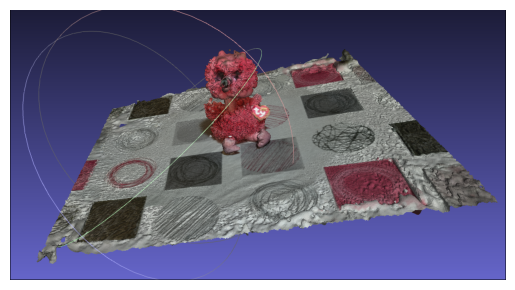

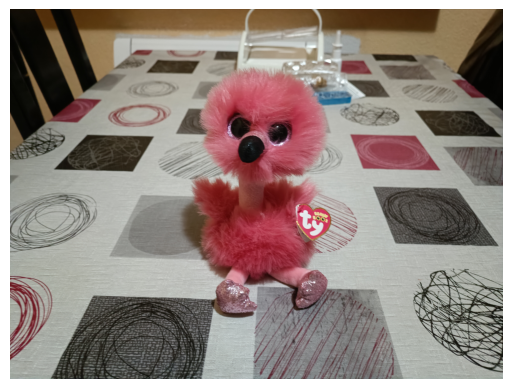

In [34]:
read_and_show("images/flamingo_poisson_clean_mesh.png")
read_and_show("images/flamingo_image.jpg")

# 5. Use Neuralangelo or Gaussian splatting to reconstruct a 3D mesh from images captured by you (Optional)

<span style="color:#1e90ff; font-weight:700; font-size:1.15em;">Explanation</span>

We chose Gaussian Splatting for this optional task. We cloned and built the github repository following the instructions in the README.md and trained the Gaussian Splatting model on the flamingo scene using an NVIDIA RTX 6000 Ada Generation. We didn't change any training option, and run the train.py using all 51 images in the dataset to train for 30 000 iterations.

We provide four images of the results, which are clearer than those from COLMAP, both in center areas and more further apart areas. However, for the outskirts of the scene, we clearly see the shape of the gaussians, as it is a region that could not be reconstructed given the small ammount of views we have of them. Also, we think there may be a limit on the number of gaussians generated and they are gathered in the center of the scene to provide a higher level of detail.

We observe some artifacts floating, which could come from outliers from the COLMAP sparse model, or be generated in the training of the Gaussian Splatting. Also the walls have smoothen givin a flat texture instead of the grainy original one.

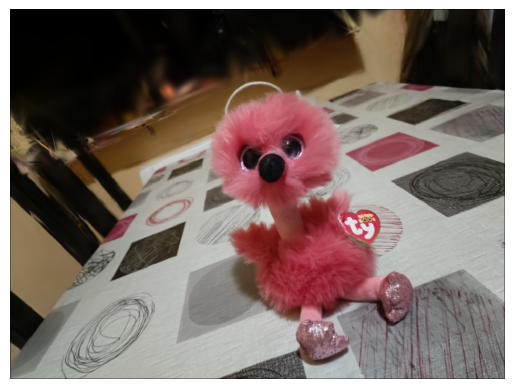

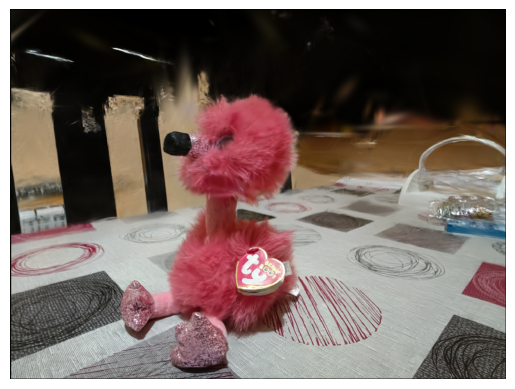

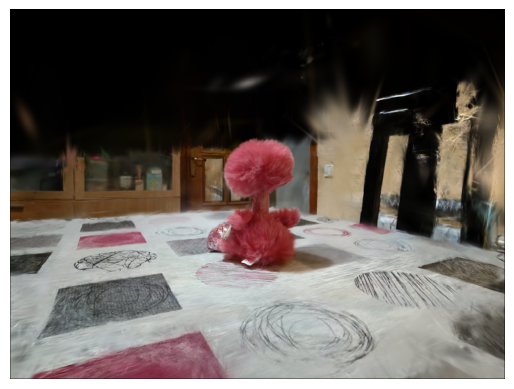

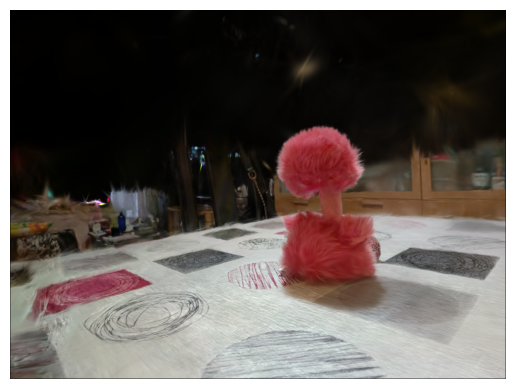

In [39]:
read_and_show("images/flamingo_gs_1.png")
read_and_show("images/flamingo_gs_2.png")
read_and_show("images/flamingo_gs_3.png")
read_and_show("images/flamingo_gs_4.png")